# DOE 분석 — % Iron / % Silica Concentrate

**데이터**: Silica_model_ready.csv (IQR 클리핑 + **Silica log 변환** + lag=3H 적용)  
**목적**: X01~X21 중 종속변수에 유의미한 변수 선별

| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 로드 |
| Step 2 | OLS 회귀 → p-value 기반 유의 변수 선별 |
| Step 3 | 주효과도 (Main Effects Plot) |
| Step 4 | VIF — 다중공선성 확인 |
| Step 5 | 최종 선별 변수 정리 |

> ⚠️ **주의**  
> - `% Silica Concentrate` 는 CSV에 **log 변환된 값**으로 저장되어 있습니다.  
>   → OLS 계수·주효과도 y축은 **log(Silica)** 단위이며, 해석 시 유의하세요.  
> - `X01(% Iron Feed)`, `X02(% Silica Feed)` 는 **공정 입력값(원광석 특성)**으로  
>   제어 불가능하지만 모델에서 반드시 포함해야 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ── Step 1. 데이터 로드 ───────────────────────────────────────────────────────
df = pd.read_csv('Silica_model_ready.csv', index_col='date', parse_dates=True)

X_COLS = [
    '% Iron Feed',          # X01 — 원광석 철 함량   (입력값, 제거 금지)
    '% Silica Feed',        # X02 — 원광석 실리카 함량 (입력값, 제거 금지)
    'Starch Flow',          # X03
    'Amina Flow',           # X04
    'Ore Pulp Flow',        # X05
    'Ore Pulp pH',          # X06
    'Ore Pulp Density',     # X07
    'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
    'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
    'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
    'Flotation Column 07 Air Flow',
    'Flotation Column 01 Level', 'Flotation Column 02 Level',
    'Flotation Column 03 Level', 'Flotation Column 04 Level',
    'Flotation Column 05 Level', 'Flotation Column 06 Level',
    'Flotation Column 07 Level',
]
X_LABELS = [f'X{str(i+1).zfill(2)}' for i in range(len(X_COLS))]

# X01, X02는 입력값이라 VIF가 높아도 절대 제거하지 않음
PROTECTED = ['X01', 'X02']

# 타겟 변수
TARGETS    = ['% Iron Concentrate', '% Silica Concentrate']
TARGET_KOR = ['철 농축물 (Iron)', 'log(실리카 농축물) — log 변환됨']

# Silica 타겟이 log 변환되었는지 표시
IS_LOG = {'% Iron Concentrate': False, '% Silica Concentrate': True}

print(f'데이터 크기: {df.shape[0]}행 × {df.shape[1]}열')
print(f'기간       : {df.index.min()} ~ {df.index.max()}')
print()
print('⚠ % Silica Concentrate 는 log 변환된 값입니다.')
display(df[TARGETS].describe().round(4))

데이터 크기: 4091행 × 23열
기간       : 2017-03-10 01:00:00 ~ 2017-09-09 20:00:00

⚠ % Silica Concentrate 는 log 변환된 값입니다.


,% Iron Concentrate,% Silica Concentrate
count,4091.0000,4091.0000
mean,65.0476,1.1507
std,1.1168,0.3140
min,62.1350,0.4700
25%,64.3600,0.8920
50%,65.2100,1.0986
75%,65.8600,1.3888
max,68.0100,1.8508


## Step 2. OLS 회귀 — p-value 기반 유의 변수 선별

X를 **표준화(StandardScaler)** 한 뒤 OLS 회귀를 돌립니다.

- **표준화 이유**: 단위가 다른 변수(pH vs 유량 등)의 계수 크기를 공정하게 비교하기 위함  
- **p < 0.05** → 이 변수가 Y에 통계적으로 유의미한 영향을 준다고 판단  
- Silica 타겟은 **log 변환된 값** 기준으로 회귀 → 계수는 log(Silica) 변화량

In [2]:
# ── Step 2. OLS 회귀 ─────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[X_COLS])
X_sm     = sm.add_constant(
    pd.DataFrame(X_scaled, columns=X_LABELS, index=df.index)
)

sig_vars = {}   # 타겟별 유의 변수 저장

for target, kor in zip(TARGETS, TARGET_KOR):
    y   = df[target]   # Silica는 이미 log 변환된 상태
    ols = sm.OLS(y, X_sm).fit()

    result = pd.DataFrame({
        'Name'   : X_COLS,
        'coef'   : ols.params[X_LABELS].values,
        'p-value': ols.pvalues[X_LABELS].values,
    }, index=X_LABELS)
    result['유의(p<0.05)'] = result['p-value'] < 0.05
    result['입력값(고정)'] = result.index.isin(PROTECTED)
    result = result.sort_values('p-value')

    # X01, X02는 유의 여부와 무관하게 항상 포함
    sig = [
        v for v in result.index
        if result.loc[v, '유의(p<0.05)'] or v in PROTECTED
    ]
    sig_vars[target] = sig

    log_note = '  ← y축: log(Silica) 단위' if IS_LOG[target] else ''
    print('=' * 65)
    print(f'  {kor}   |  R² = {ols.rsquared:.4f}{log_note}')
    print('=' * 65)
    display(result.round(4))
    print(f'  → 선택 변수 ({len(sig)}개): {sig}')
    print(f'     (X01·X02는 입력값이므로 p값 무관하게 포함)\n')

  철 농축물 (Iron)   |  R² = 0.1297


,Name,coef,p-value,유의(p<0.05),입력값(고정)
X06,Ore Pulp pH,0.2068,0.0000,True,False
X12,Flotation Column 05 Air Flow,0.1436,0.0000,True,False
X04,Amina Flow,-0.1370,0.0000,True,False
X11,Flotation Column 04 Air Flow,-0.1250,0.0000,True,False
X13,Flotation Column 06 Air Flow,-0.1815,0.0000,True,False
X05,Ore Pulp Flow,0.0783,0.0000,True,False
X19,Flotation Column 05 Level,0.1341,0.0001,True,False
X02,% Silica Feed,0.2464,0.0006,True,True
X09,Flotation Column 02 Air Flow,-0.1238,0.0008,True,False
X01,% Iron Feed,0.2200,0.0024,True,True


  → 선택 변수 (14개): ['X06', 'X12', 'X04', 'X11', 'X13', 'X05', 'X19', 'X02', 'X09', 'X01', 'X14', 'X07', 'X08', 'X10']
     (X01·X02는 입력값이므로 p값 무관하게 포함)

  log(실리카 농축물) — log 변환됨   |  R² = 0.1353  ← y축: log(Silica) 단위


,Name,coef,p-value,유의(p<0.05),입력값(고정)
X06,Ore Pulp pH,-0.0430,0.0000,True,False
X04,Amina Flow,0.0400,0.0000,True,False
X08,Flotation Column 01 Air Flow,-0.0861,0.0000,True,False
X11,Flotation Column 04 Air Flow,0.0297,0.0000,True,False
X13,Flotation Column 06 Air Flow,0.0419,0.0007,True,False
X19,Flotation Column 05 Level,-0.0316,0.0011,True,False
X12,Flotation Column 05 Air Flow,-0.0153,0.0045,True,False
X18,Flotation Column 04 Level,-0.0228,0.0054,True,False
X17,Flotation Column 03 Level,0.0165,0.0433,True,False
X01,% Iron Feed,-0.0351,0.0838,False,True


  → 선택 변수 (11개): ['X06', 'X04', 'X08', 'X11', 'X13', 'X19', 'X12', 'X18', 'X17', 'X01', 'X02']
     (X01·X02는 입력값이므로 p값 무관하게 포함)



## Step 3. 주효과도 (Main Effects Plot)

각 변수를 **5분위(Q1~Q5)** 로 나눠 구간별 Y 평균을 시각화합니다.

- 기울기가 **가파를수록** 해당 변수의 영향이 큼  
- 노란 배경 = p < 0.05 유의 변수  
- 파란 테두리 = X01·X02 (입력값, 고정 포함)  
- **Silica 그래프의 y축은 log(Silica) 단위** — 실제 값이 아님에 주의

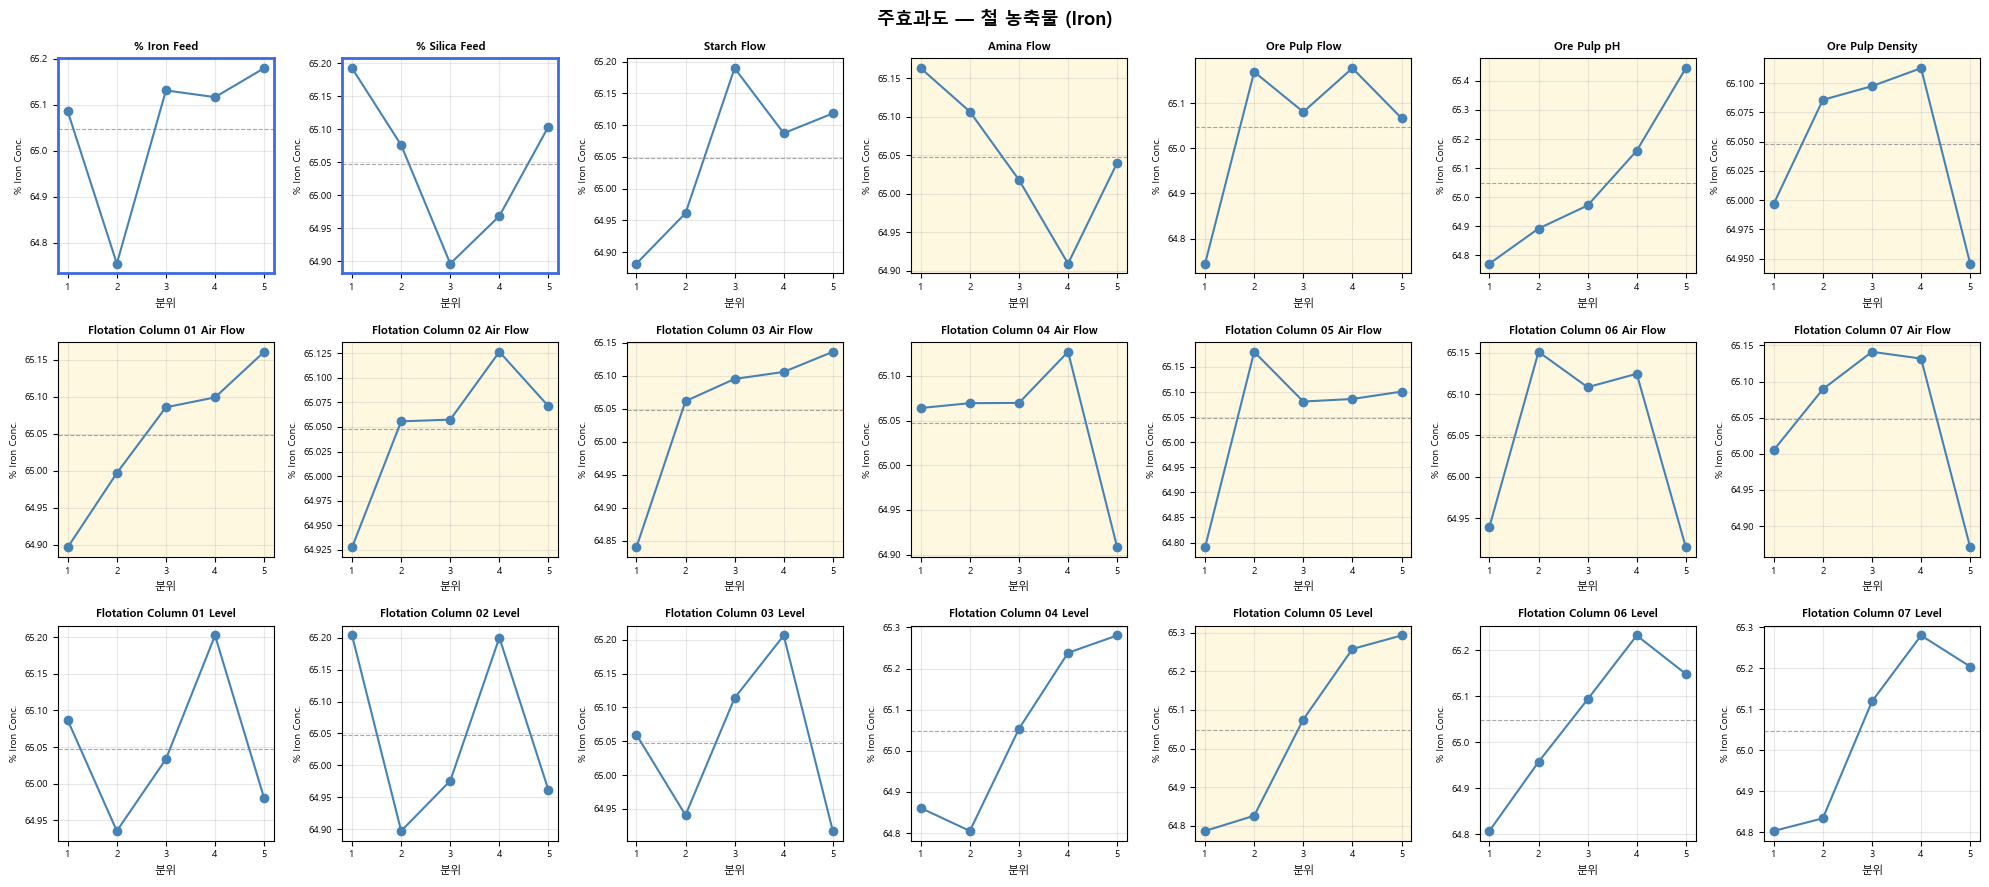

저장 완료: main_effects_%_Iro.png
  노란 배경 = p<0.05 유의 변수  |  파란 테두리 = 입력값(X01·X02)


C:\Users\USER\AppData\Local\Temp\ipykernel_22812\2780933511.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(fname, dpi=120, bbox_inches='tight')
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


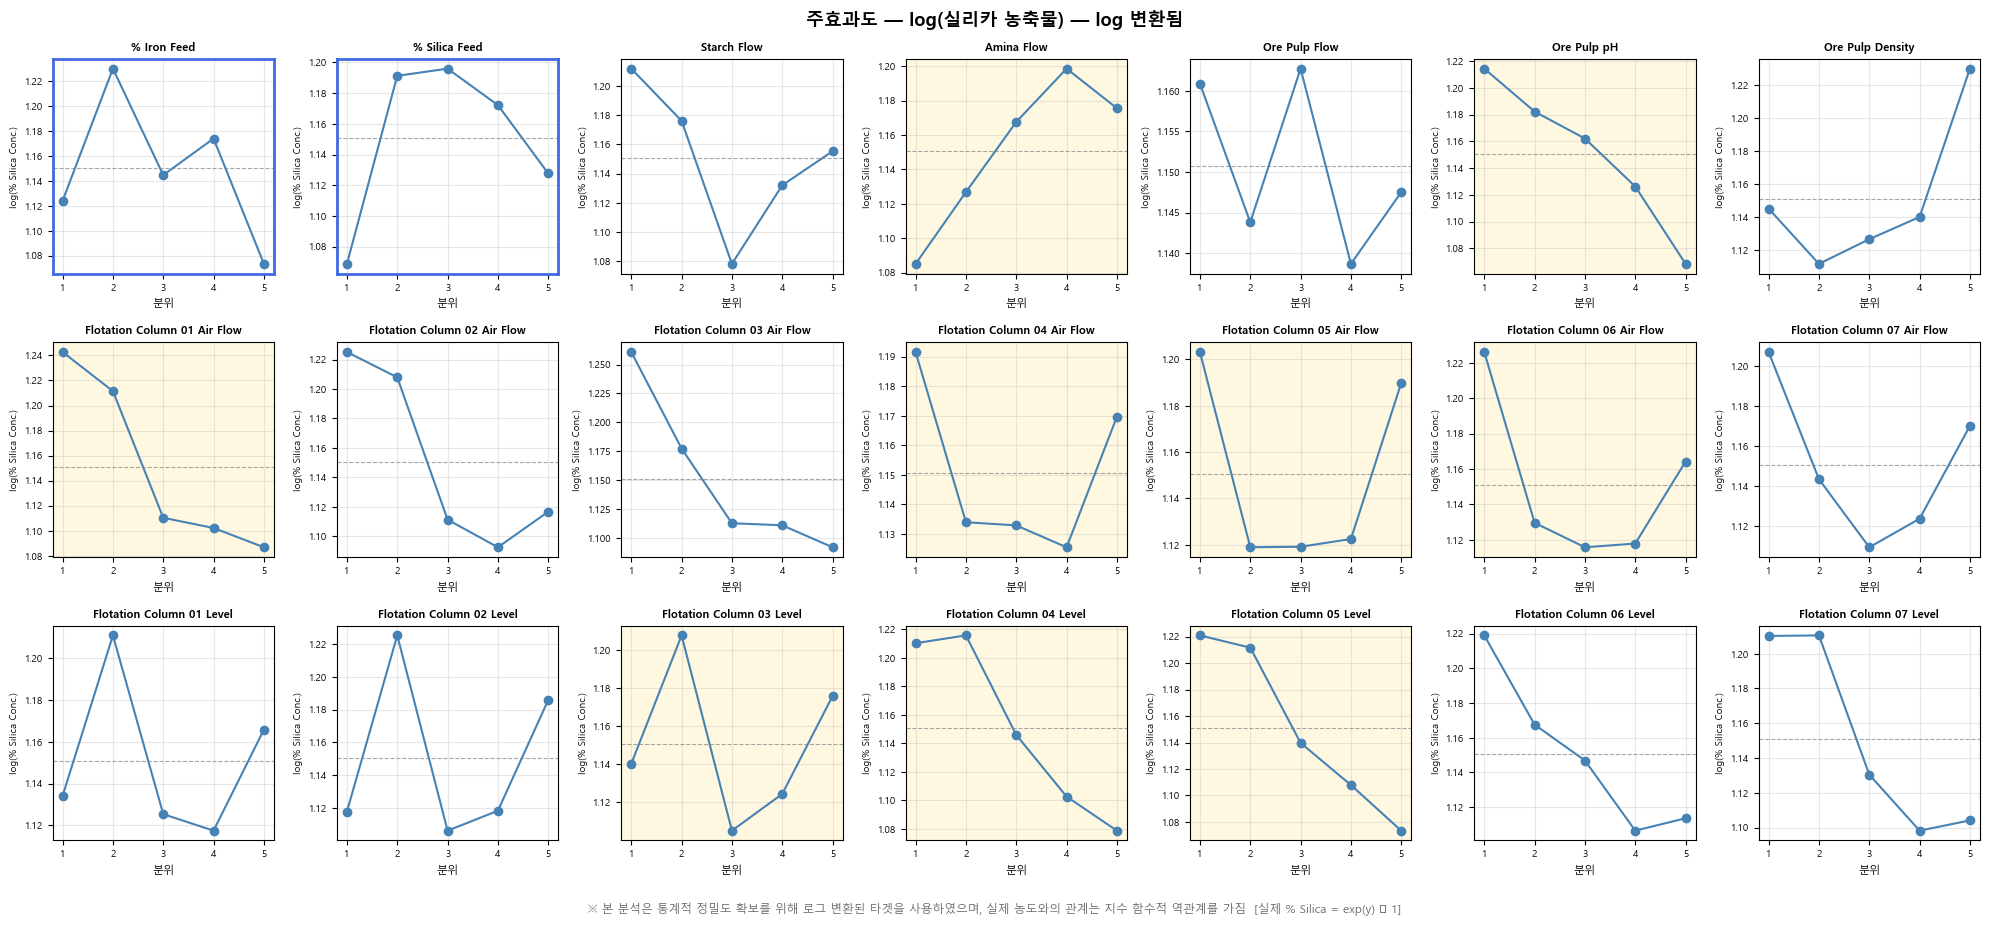

저장 완료: main_effects_%_Sil.png
  노란 배경 = p<0.05 유의 변수  |  파란 테두리 = 입력값(X01·X02)


In [3]:
# ── Step 3. 주효과도 ──────────────────────────────────────────────────────────
N_QUANTILE = 5

for target, kor in zip(TARGETS, TARGET_KOR):
    ncols = 7
    nrows = (len(X_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
    y_label = 'log(% Silica Conc.)' if IS_LOG[target] else '% Iron Conc.'
    fig.suptitle(f'주효과도 — {kor}', fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i, (col, lbl) in enumerate(zip(X_COLS, X_LABELS)):
        ax    = axes[i]
        q_bin = pd.qcut(df[col], N_QUANTILE, labels=False, duplicates='drop')
        means = df.groupby(q_bin)[target].mean()
        ax.plot(means.index + 1, means.values, 'o-', color='steelblue', lw=1.5)
        ax.axhline(df[target].mean(), color='gray', ls='--', lw=0.8, alpha=0.7)
        ax.set_title(f'{col}', fontsize=8, fontweight='bold')
        ax.set_xlabel('분위', fontsize=8)
        ax.set_ylabel(y_label, fontsize=7)
        ax.set_xticks(range(1, N_QUANTILE + 1))
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

        # 유의 변수 강조 (노란 배경)
        if lbl in sig_vars[target] and lbl not in PROTECTED:
            ax.set_facecolor('#fff8e1')
        # 입력값(X01·X02) 파란 테두리 강조
        if lbl in PROTECTED:
            for spine in ax.spines.values():
                spine.set_edgecolor('royalblue')
                spine.set_linewidth(2)

    for j in range(len(X_COLS), len(axes)):
        axes[j].set_visible(False)

    # Silica 그래프 하단 주석 (log 변환 안내)
    if IS_LOG[target]:
        fig.text(
            0.5, -0.012,
            '※ 본 분석은 통계적 정밀도 확보를 위해 로그 변환된 타겟을 사용하였으며, '
            '실제 농도와의 관계는 지수 함수적 역관계를 가짐  [실제 % Silica = exp(y) − 1]',
            ha='center', va='top', fontsize=8.5, color='dimgray', style='italic'
        )
    plt.tight_layout()
    fname = f'main_effects_{target[:5].strip().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'저장 완료: {fname}')
    print(f'  노란 배경 = p<0.05 유의 변수  |  파란 테두리 = 입력값(X01·X02)')


## Step 4. VIF — 다중공선성 확인

**VIF(Variance Inflation Factor)**: 변수 간 중복 정보가 얼마나 큰지 측정

| VIF 값 | 해석 |
|--------|------|
| 1~5    | 양호 |
| 5~10   | 주의 |
| > 10   | 제거 고려 |

> ⚠️ **X01, X02는 VIF가 10을 넘어도 제거하지 않습니다.**  
> 입력값(원광석 특성)은 공정 외부에서 들어오는 값으로, 모델에 필수적으로 포함해야 합니다.

In [4]:
# ── Step 4. VIF ───────────────────────────────────────────────────────────────
# 두 타겟의 선택 변수 합집합 기준으로 VIF 계산
all_sig = list(dict.fromkeys(
    sig_vars[TARGETS[0]] + sig_vars[TARGETS[1]]
))  # 순서 보존

if len(all_sig) < 2:
    print('유의 변수가 너무 적어 VIF 계산 생략')
else:
    sig_col_names = [X_COLS[X_LABELS.index(v)] for v in all_sig]
    X_vif = pd.DataFrame(
        scaler.fit_transform(df[sig_col_names]),
        columns=all_sig
    )
    vif_df = pd.DataFrame({
        'Var' : all_sig,
        'Name': sig_col_names,
        'VIF' : [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    def vif_label(row):
        if row['Var'] in PROTECTED:
            return '입력값 — 제거 금지'
        elif row['VIF'] > 10:
            return '⚠ 제거 고려'
        return ''

    vif_df['비고'] = vif_df.apply(vif_label, axis=1)
    print('=== VIF 결과 (선택 변수 기준) ===')
    display(vif_df.round(2))

    # X01·X02는 제외하고 VIF 초과 변수만 제거
    high_vif = vif_df[
        (vif_df['VIF'] > 10) & (~vif_df['Var'].isin(PROTECTED))
    ]['Var'].tolist()
    print(f'\nVIF > 10이면서 제거 가능한 변수: {high_vif if high_vif else "없음"}')
    print('(X01·X02는 VIF 무관 유지)')

=== VIF 결과 (선택 변수 기준) ===


,Var,Name,VIF,비고
0,X01,% Iron Feed,19.45,입력값 — 제거 금지
1,X02,% Silica Feed,19.15,입력값 — 제거 금지
2,X10,Flotation Column 03 Air Flow,16.13,⚠ 제거 고려
3,X08,Flotation Column 01 Air Flow,13.97,⚠ 제거 고려
4,X14,Flotation Column 07 Air Flow,7.45,
5,X13,Flotation Column 06 Air Flow,6.90,
6,X09,Flotation Column 02 Air Flow,5.04,
7,X19,Flotation Column 05 Level,3.02,
8,X18,Flotation Column 04 Level,2.73,
9,X04,Amina Flow,2.25,



VIF > 10이면서 제거 가능한 변수: ['X10', 'X08']
(X01·X02는 VIF 무관 유지)


## Step 5. RSM + Backward Elimination (단계 집계 변수)

**주효과도에서 관찰한 구조:**
- Rougher 단계 (Col01~03): 초기 거품 형성, Air 지배적
- Cleaner 단계 (Col04~07): 정밀 실리카 제거, Level 지배적

**14개 개별 컬럼 → 4개 집계 변수로 압축:**

| 변수 | 정의 | 의미 |
|------|------|------|
| Rougher_Air | Air Col01~03 평균 | 앞단 Air 세기 |
| Cleaner_Air | Air Col04~07 평균 | 뒷단 Air 세기 |
| Rougher_Level | Level Col01~03 평균 | 앞단 거품층 높이 |
| Cleaner_Level | Level Col04~07 평균 | 뒷단 거품층 높이 |

**인과 쌍 교호작용 제외**: Rougher_Air × Rougher_Level, Cleaner_Air × Cleaner_Level  
(같은 단계 내 Air → Level 인과 관계)

**보호 변수**: % Iron Feed, % Silica Feed (p값 무관 항상 포함)

In [5]:
from itertools import combinations

# ── Step 5-1. 단계 집계 변수 생성 ─────────────────────────────────────────────
AIR_COLS   = [c for c in X_COLS if 'Air Flow' in c]
LEVEL_COLS = [c for c in X_COLS if 'Level' in c]

rougher_air_cols   = AIR_COLS[:3]    # Col01~03 Air
cleaner_air_cols   = AIR_COLS[3:]    # Col04~07 Air
rougher_level_cols = LEVEL_COLS[:3]  # Col01~03 Level
cleaner_level_cols = LEVEL_COLS[3:]  # Col04~07 Level

df_rsm = pd.DataFrame(index=df.index)

# 공정 투입 변수 (7개)
PROCESS_LABELS = ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07']
for col, lbl in zip(X_COLS[:7], PROCESS_LABELS):
    df_rsm[lbl] = df[col]

# 단계 집계 변수 (4개) — 비율 변수 제외
df_rsm['RA'] = df[rougher_air_cols].mean(axis=1)
df_rsm['CA'] = df[cleaner_air_cols].mean(axis=1)
df_rsm['RL'] = df[rougher_level_cols].mean(axis=1)
df_rsm['CL'] = df[cleaner_level_cols].mean(axis=1)

VAR_LABELS = list(df_rsm.columns)  # 11개
VAR_NAMES  = {
    'P01': '% Iron Feed',              'P02': '% Silica Feed',
    'P03': 'Starch Flow',              'P04': 'Amina Flow',
    'P05': 'Ore Pulp Flow',            'P06': 'Ore Pulp pH',
    'P07': 'Ore Pulp Density',
    'RA' : 'Rougher Air (Col01~03)',   'CA' : 'Cleaner Air (Col04~07)',
    'RL' : 'Rougher Level (Col01~03)', 'CL' : 'Cleaner Level (Col04~07)',
}
PROTECTED_RSM = ['P01', 'P02']

# Air→Level 인과 쌍 (같은 단계 내 교호작용 제외)
CAUSAL_PAIRS = {('RA', 'RL'), ('CA', 'CL')}

print('=== RSM 입력 변수 ===')
for lbl in VAR_LABELS:
    tag = '  ← 보호 변수' if lbl in PROTECTED_RSM else ''
    print(f'  {lbl:4s}: {VAR_NAMES[lbl]}{tag}')

print(f'\nRougher Air  : {rougher_air_cols}')
print(f'Cleaner Air  : {cleaner_air_cols}')
print(f'Rougher Level: {rougher_level_cols}')
print(f'Cleaner Level: {cleaner_level_cols}')
print(f'\n인과 쌍 (교호작용 제외): {CAUSAL_PAIRS}')
print(f'\n결측값 확인:\n{df_rsm.isnull().sum()[df_rsm.isnull().sum() > 0]}')
if df_rsm.isnull().sum().sum() == 0:
    print('  결측값 없음')

=== RSM 입력 변수 ===
  P01 : % Iron Feed  ← 보호 변수
  P02 : % Silica Feed  ← 보호 변수
  P03 : Starch Flow
  P04 : Amina Flow
  P05 : Ore Pulp Flow
  P06 : Ore Pulp pH
  P07 : Ore Pulp Density
  RA  : Rougher Air (Col01~03)
  CA  : Cleaner Air (Col04~07)
  RL  : Rougher Level (Col01~03)
  CL  : Cleaner Level (Col04~07)

Rougher Air  : ['Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow']
Cleaner Air  : ['Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow']
Rougher Level: ['Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level']
Cleaner Level: ['Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']

인과 쌍 (교호작용 제외): {('CA', 'CL'), ('RA', 'RL')}

결측값 확인:
Series([], dtype: int64)
  결측값 없음


In [6]:
# ── Step 5-2. RSM 항 생성 + Backward Elimination ──────────────────────────────
scaler_rsm   = StandardScaler()
X_rsm_scaled = scaler_rsm.fit_transform(df_rsm)
X_rsm_df     = pd.DataFrame(X_rsm_scaled, columns=VAR_LABELS, index=df.index)

rsm_terms = {}

# 주효과 (13개)
for lbl in VAR_LABELS:
    rsm_terms[lbl] = X_rsm_df[lbl]

# 2차항 (13개)
for lbl in VAR_LABELS:
    rsm_terms[f'{lbl}^2'] = X_rsm_df[lbl] ** 2

# 교호작용 (인과 쌍 제외)
for a, b in combinations(VAR_LABELS, 2):
    if (a, b) not in CAUSAL_PAIRS and (b, a) not in CAUSAL_PAIRS:
        rsm_terms[f'{a}x{b}'] = X_rsm_df[a] * X_rsm_df[b]

X_rsm_full = sm.add_constant(pd.DataFrame(rsm_terms, index=df.index))

n_main  = len(VAR_LABELS)
n_quad  = len(VAR_LABELS)
n_inter = len(rsm_terms) - n_main - n_quad
print(f'RSM 항 수: {X_rsm_full.shape[1] - 1}개 (절편 제외)')
print(f'  주효과: {n_main}개 | 2차항: {n_quad}개 | 교호작용: {n_inter}개')
print(f'  (인과 쌍 {len(CAUSAL_PAIRS)}개 교호작용 제외)')

# 항 이름 변환 함수
def term_to_name(term):
    if '^2' in term:
        lbl = term.replace('^2', '')
        return f'{VAR_NAMES.get(lbl, lbl)}²'
    elif 'x' in term:
        a, b = term.split('x', 1)
        return f'{VAR_NAMES.get(a, a)} × {VAR_NAMES.get(b, b)}'
    return VAR_NAMES.get(term, term)

# ── Backward Elimination ───────────────────────────────────────────────────────
y             = df['% Silica Concentrate']
current_terms = list(X_rsm_full.columns)
keep_terms    = set(['const'] + PROTECTED_RSM)
iteration     = 0

print('\nBackward Elimination 시작...')
while True:
    model     = sm.OLS(y, X_rsm_full[current_terms]).fit()
    removable = {t: p for t, p in model.pvalues.items() if t not in keep_terms}
    max_p     = max(removable.values())

    if max_p <= 0.05:
        break

    worst = max(removable, key=removable.get)
    current_terms.remove(worst)
    iteration += 1

    if iteration % 10 == 0:
        print(f'  iter {iteration:3d} | 제거: {term_to_name(worst):50s} | p={max_p:.4f} | 남은 항: {len(current_terms)-1}')

print(f'\n완료: {iteration}회 반복 | 최종 항 수: {len(current_terms)-1}개')

# ── 최종 결과 ──────────────────────────────────────────────────────────────────
final_model  = sm.OLS(y, X_rsm_full[current_terms]).fit()
final_result = pd.DataFrame({
    'Feature': [term_to_name(t) for t in final_model.params.index if t != 'const'],
    'coef'   : final_model.params.drop('const').values,
    'p-value': final_model.pvalues.drop('const').values,
}, index=final_model.params.drop('const').index).sort_values('p-value')

print(f'\n=== 최종 RSM 모델 | R² = {final_model.rsquared:.4f} | 타겟: log(Silica) ===')
display(final_result.round(4))

# 유형별 요약
sig_main  = [t for t in final_result.index if '^2' not in t and 'x' not in t]
sig_quad  = [t for t in final_result.index if '^2' in t]
sig_inter = [t for t in final_result.index if 'x' in t]

print(f'\n유의 주효과   ({len(sig_main)}개): {[term_to_name(t) for t in sig_main]}')
print(f'유의 2차항    ({len(sig_quad)}개): {[term_to_name(t) for t in sig_quad]}')
print(f'유의 교호작용 ({len(sig_inter)}개): {[term_to_name(t) for t in sig_inter]}')
print('\n→ XGBoost 피처 후보: 유의 주효과 변수 (원본 집계값 기준)')

RSM 항 수: 75개 (절편 제외)
  주효과: 11개 | 2차항: 11개 | 교호작용: 53개
  (인과 쌍 2개 교호작용 제외)

Backward Elimination 시작...
  iter  10 | 제거: Starch Flow × Amina Flow                           | p=0.6500 | 남은 항: 65
  iter  20 | 제거: Starch Flow × Ore Pulp pH                          | p=0.4079 | 남은 항: 55
  iter  30 | 제거: Cleaner Air (Col04~07)                             | p=0.1206 | 남은 항: 45
  iter  40 | 제거: Ore Pulp Flow × Ore Pulp pH                        | p=0.0625 | 남은 항: 35

완료: 40회 반복 | 최종 항 수: 35개

=== 최종 RSM 모델 | R² = 0.1855 | 타겟: log(Silica) ===


,Feature,coef,p-value
P06,Ore Pulp pH,-0.0520,0.0000
CL,Cleaner Level (Col04~07),-0.0536,0.0000
CL^2,Cleaner Level (Col04~07)²,0.0416,0.0000
RA,Rougher Air (Col01~03),-0.0650,0.0000
P04,Amina Flow,0.0408,0.0000
P05xCA,Ore Pulp Flow × Cleaner Air (Col04~07),-0.0393,0.0000
P02xCL,% Silica Feed × Cleaner Level (Col04~07),0.1579,0.0000
P01xCL,% Iron Feed × Cleaner Level (Col04~07),0.1599,0.0000
P01xRA,% Iron Feed × Rougher Air (Col01~03),-0.2169,0.0000
P02xRA,% Silica Feed × Rougher Air (Col01~03),-0.2005,0.0000



유의 주효과   (6개): ['Ore Pulp pH', 'Cleaner Level (Col04~07)', 'Rougher Air (Col01~03)', 'Amina Flow', '% Iron Feed', '% Silica Feed']
유의 2차항    (6개): ['Cleaner Level (Col04~07)²', 'Starch Flow²', 'Rougher Level (Col01~03)²', 'Ore Pulp Flow²', 'Rougher Air (Col01~03)²', 'Amina Flow²']
유의 교호작용 (23개): ['Ore Pulp Flow × Cleaner Air (Col04~07)', '% Silica Feed × Cleaner Level (Col04~07)', '% Iron Feed × Cleaner Level (Col04~07)', '% Iron Feed × Rougher Air (Col01~03)', '% Silica Feed × Rougher Air (Col01~03)', '% Silica Feed × Amina Flow', '% Iron Feed × Cleaner Air (Col04~07)', '% Silica Feed × Cleaner Air (Col04~07)', '% Iron Feed × Rougher Level (Col01~03)', '% Silica Feed × Rougher Level (Col01~03)', 'Starch Flow × Cleaner Level (Col04~07)', '% Iron Feed × Amina Flow', '% Silica Feed × Ore Pulp pH', 'Amina Flow × Cleaner Air (Col04~07)', '% Silica Feed × Ore Pulp Flow', 'Amina Flow × Ore Pulp Flow', 'Ore Pulp pH × Rougher Level (Col01~03)', 'Ore Pulp pH × Ore Pulp Density', 'Ore Pulp Flow

## Step 6. XGBoost 비교 실험 — 실험 A vs 실험 B

**선행 논문 방법론 준수:**
- Time-Lag 3H (데이터에 이미 적용됨)
- Y_{t-1}, Y_{t-2} 시계열 피처 추가
- Train 70% / Test 30% (시계열 순서 유지)
- 10-fold Cross-validation

| | 실험 A | 실험 B |
|--|--------|--------|
| 방식 | 선행 논문 재현 (전체 변수) | RSM 기반 피처 선별 |
| 피처 | 21개 원본 변수 + lag1, lag2 | RSM 선별 집계 변수 + lag1, lag2 |

> ※ RMSE는 log(Silica) 단위 — 선행 논문 RMSE 0.6873(원본 단위)과 직접 비교 불가  
> 선행 논문은 방법론 근거(3H lag, 70/30, 10-fold CV)로만 인용

In [7]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# ── lag 피처 추가 ──────────────────────────────────────────────────────────────
TARGET = '% Silica Concentrate'

df['Silica_lag1'] = df[TARGET].shift(1)
df['Silica_lag2'] = df[TARGET].shift(2)
df_rsm['Silica_lag1'] = df['Silica_lag1']
df_rsm['Silica_lag2'] = df['Silica_lag2']

valid_idx = df.dropna(subset=['Silica_lag1', 'Silica_lag2']).index

# ── 실험 A: 전체 21개 변수 + lag (선행 논문 방식) ─────────────────────────────
feat_A = X_COLS + ['Silica_lag1', 'Silica_lag2']
X_A    = df.loc[valid_idx, feat_A]
y      = df.loc[valid_idx, TARGET]

# ── Train/Test 분할 (70/30, 시계열 순서 유지) ──────────────────────────────────
split = int(len(valid_idx) * 0.7)

X_A_train, X_A_test = X_A.iloc[:split], X_A.iloc[split:]
y_train, y_test     = y.iloc[:split],   y.iloc[split:]

# feat_B, X_B, X_B_train, X_B_test 는 VIF 셀에서 확정됨
print(f'Train: {len(y_train)}행 | Test: {len(y_test)}행')
print(f'실험 A 피처: {len(feat_A)}개')
print('실험 B 피처: VIF 셀 실행 후 확정')

Train: 2862행 | Test: 1227행
실험 A 피처: 23개
실험 B 피처: VIF 셀 실행 후 확정


In [8]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

NAME_MAP = {
    'P01': '% Iron Feed',
    'P02': '% Silica Feed',
    'P03': 'Starch Flow',
    'P04': 'Amina Flow',
    'P06': 'Ore Pulp pH',
    'RA' : 'Rougher Air (Col01~03)',
    'CA' : 'Cleaner Air (Col04~07)',
    'RL' : 'Rougher Level (Col01~03)',
    'CL' : 'Cleaner Level (Col04~07)',
}

def calc_vif(df_in):
    X_c  = sm.add_constant(df_in)
    cols = df_in.columns.tolist()
    vifs = [variance_inflation_factor(X_c.values, i + 1) for i in range(len(cols))]
    return pd.DataFrame({
        '변수'  : cols,
        '피처명': [NAME_MAP.get(c, c) for c in cols],
        'VIF'   : vifs
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

# LR(Level 비율) 제외 — XGBoost 성능 비교 결과 제거 시 성능 향상 확인
# P03(Starch) 강제 포함 — SI 최적화 단계에서 필요
PROTECTED = {'P01', 'P02', 'P03'}
remaining  = ['P01', 'P02', 'P03', 'P04', 'P06', 'RA', 'CL', 'CA', 'RL']
X_vif      = df_rsm.loc[valid_idx, remaining].dropna()

print('── 1차 VIF ───────────────────────────────────────────────────')
print(calc_vif(X_vif[remaining])[['피처명', 'VIF']].to_string(index=False))

# ── 순차 제거 — 비보호 변수 중 VIF > 10인 것만 제거 ──────────────────────────
print('\n── 순차 제거 과정 ────────────────────────────────────────────')
removed = []
while True:
    vif_df     = calc_vif(X_vif[remaining])
    candidates = vif_df[(vif_df['VIF'] > 10) & (~vif_df['변수'].isin(PROTECTED))]
    if candidates.empty:
        print('  ✓ 비보호 변수 중 VIF > 10 없음 — 종료')
        break
    target = candidates.iloc[0]['변수']
    name   = NAME_MAP.get(target, target)
    print(f'  제거: {name:<35s}  VIF = {candidates.iloc[0]["VIF"]:.2f}')
    remaining.remove(target)
    removed.append(target)

print(f'\n최종 유지 변수 ({len(remaining)}개):')
for v in remaining:
    print(f'  {NAME_MAP.get(v, v)}')
if removed:
    print(f'\n제거된 변수 ({len(removed)}개):')
    for v in removed:
        print(f'  {NAME_MAP.get(v, v)}')

print('\n── 최종 VIF ──────────────────────────────────────────────────')
print(calc_vif(X_vif[remaining])[['피처명', 'VIF']].to_string(index=False))

# feat_B 업데이트
feat_B    = remaining + ['Silica_lag1', 'Silica_lag2']
X_B       = df_rsm.loc[valid_idx, feat_B]
X_B_train = X_B.iloc[:split]
X_B_test  = X_B.iloc[split:]
print(f'\nfeat_B 업데이트 완료 ({len(feat_B)}개): {[NAME_MAP.get(f, f) for f in feat_B]}')

── 1차 VIF ───────────────────────────────────────────────────
                     피처명       VIF
           % Silica Feed 18.611468
             % Iron Feed 18.608010
  Rougher Air (Col01~03)  2.351711
  Cleaner Air (Col04~07)  2.245636
Rougher Level (Col01~03)  1.906972
             Starch Flow  1.532431
Cleaner Level (Col04~07)  1.453597
              Amina Flow  1.249121
             Ore Pulp pH  1.156086

── 순차 제거 과정 ────────────────────────────────────────────
  ✓ 비보호 변수 중 VIF > 10 없음 — 종료

최종 유지 변수 (9개):
  % Iron Feed
  % Silica Feed
  Starch Flow
  Amina Flow
  Ore Pulp pH
  Rougher Air (Col01~03)
  Cleaner Level (Col04~07)
  Cleaner Air (Col04~07)
  Rougher Level (Col01~03)

── 최종 VIF ──────────────────────────────────────────────────
                     피처명       VIF
           % Silica Feed 18.611468
             % Iron Feed 18.608010
  Rougher Air (Col01~03)  2.351711
  Cleaner Air (Col04~07)  2.245636
Rougher Level (Col01~03)  1.906972
             Starch Flow  1.532431
Cl

In [9]:
# ── XGBoost 실험 함수 ──────────────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
)
K = 10

def run_experiment(X_tr, X_te, label):
    # 10-fold CV (수동 구현 — XGBoost + sklearn 호환 이슈 대응)
    fold_size = len(X_tr) // K
    cv_rmses  = []

    for k in range(K):
        val_start = k * fold_size
        val_end   = (k + 1) * fold_size if k < K - 1 else len(X_tr)
        val_idx   = list(range(val_start, val_end))
        tr_idx    = list(range(0, val_start)) + list(range(val_end, len(X_tr)))

        model = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
        model.fit(X_tr.iloc[tr_idx], y_train.iloc[tr_idx])
        pred  = model.predict(X_tr.iloc[val_idx])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], pred)))

    cv_rmse = np.mean(cv_rmses)
    cv_std  = np.std(cv_rmses)

    # 전체 train으로 최종 모델 학습
    final = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
    final.fit(X_tr, y_train)
    pred_test = final.predict(X_te)

    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2   = 1 - np.sum((y_test - pred_test)**2) / np.sum((y_test - y_test.mean())**2)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  피처 수  : {X_tr.shape[1]}개')
    print(f'  CV RMSE  : {cv_rmse:.4f} ± {cv_std:.4f}')
    print(f'  Test RMSE: {test_rmse:.4f}')
    print(f'  Test R²  : {test_r2:.4f}')

    return final, {'cv_rmse': cv_rmse, 'cv_std': cv_std,
                   'test_rmse': test_rmse, 'test_r2': test_r2}

model_A, res_A = run_experiment(X_A_train, X_A_test, '실험 A — 전체 21개 변수 (선행 논문 방식)')
model_B, res_B = run_experiment(X_B_train, X_B_test, '실험 B — RSM 선별 집계 변수 (우리 방식)')

# ── 최종 비교표 ────────────────────────────────────────────────────────────────
rmse_impr = (res_A['test_rmse'] - res_B['test_rmse']) / res_A['test_rmse'] * 100
r2_impr   = res_B['test_r2'] - res_A['test_r2']

print(f'\n{"="*55}')
print(f'  최종 비교')
print(f'{"="*55}')
print(f'{"":22s}  {"실험 A":>8s}  {"실험 B":>8s}  {"개선":>7s}')
print(f'  {"피처 수":20s}  {len(feat_A):>8d}  {len(feat_B):>8d}')
print(f'  {"CV RMSE":20s}  {res_A["cv_rmse"]:>8.4f}  {res_B["cv_rmse"]:>8.4f}')
print(f'  {"Test RMSE":20s}  {res_A["test_rmse"]:>8.4f}  {res_B["test_rmse"]:>8.4f}  {rmse_impr:>+6.2f}%')
print(f'  {"Test R²":20s}  {res_A["test_r2"]:>8.4f}  {res_B["test_r2"]:>8.4f}  {r2_impr:>+6.4f}')
print(f'\n선행 논문 XGBoost RMSE: 0.6873 (원본 단위 — 방법론 참고용)')
print('※ 본 실험 RMSE는 log(Silica) 단위')


  실험 A — 전체 21개 변수 (선행 논문 방식)
  피처 수  : 23개
  CV RMSE  : 0.2109 ± 0.0216
  Test RMSE: 0.2289
  Test R²  : 0.4541

  실험 B — RSM 선별 집계 변수 (우리 방식)
  피처 수  : 11개
  CV RMSE  : 0.2120 ± 0.0206
  Test RMSE: 0.2132
  Test R²  : 0.5265

  최종 비교
                            실험 A      실험 B       개선
  피처 수                        23        11
  CV RMSE                 0.2109    0.2120
  Test RMSE               0.2289    0.2132   +6.87%
  Test R²                 0.4541    0.5265  +0.0724

선행 논문 XGBoost RMSE: 0.6873 (원본 단위 — 방법론 참고용)
※ 본 실험 RMSE는 log(Silica) 단위


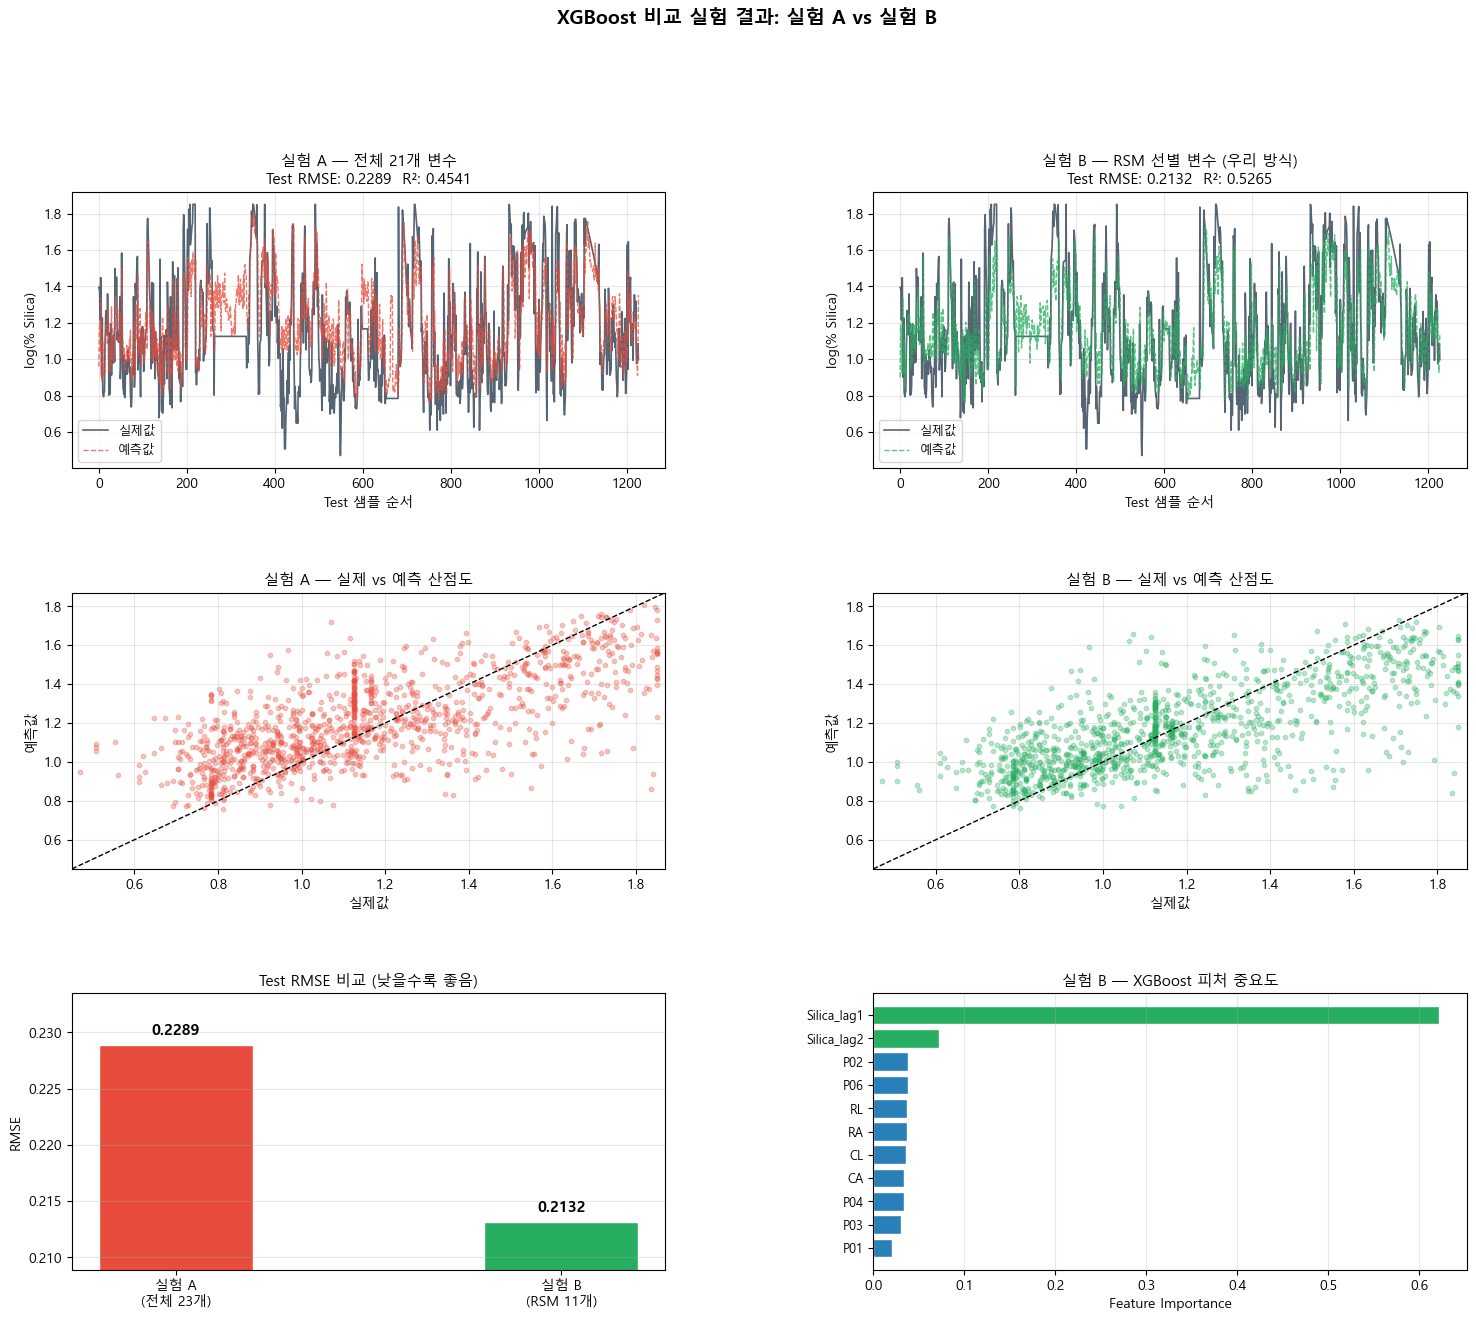

저장 완료: xgb_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

plt.rcParams['font.family']     = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pred_A = model_A.predict(X_A_test)
pred_B = model_B.predict(X_B_test)
y_arr  = y_test.values
x_time = np.arange(len(y_arr))

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── (1) 실제 vs 예측 — 실험 A ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x_time, y_arr,  color='#2c3e50', lw=1.2, label='실제값', alpha=0.8)
ax1.plot(x_time, pred_A, color='#e74c3c', lw=1.0, label='예측값', alpha=0.75, linestyle='--')
ax1.set_title(f'실험 A — 전체 21개 변수\nTest RMSE: {res_A["test_rmse"]:.4f}  R²: {res_A["test_r2"]:.4f}', fontsize=11)
ax1.set_xlabel('Test 샘플 순서'); ax1.set_ylabel('log(% Silica)')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── (2) 실제 vs 예측 — 실험 B ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x_time, y_arr,  color='#2c3e50', lw=1.2, label='실제값', alpha=0.8)
ax2.plot(x_time, pred_B, color='#27ae60', lw=1.0, label='예측값', alpha=0.75, linestyle='--')
ax2.set_title(f'실험 B — RSM 선별 변수 (우리 방식)\nTest RMSE: {res_B["test_rmse"]:.4f}  R²: {res_B["test_r2"]:.4f}', fontsize=11)
ax2.set_xlabel('Test 샘플 순서'); ax2.set_ylabel('log(% Silica)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── (3) 산점도 — 실험 A ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_arr, pred_A, alpha=0.3, s=10, color='#e74c3c')
lim = [min(y_arr.min(), pred_A.min()) - 0.02, max(y_arr.max(), pred_A.max()) + 0.02]
ax3.plot(lim, lim, 'k--', lw=1)
ax3.set_xlim(lim); ax3.set_ylim(lim)
ax3.set_title('실험 A — 실제 vs 예측 산점도', fontsize=11)
ax3.set_xlabel('실제값'); ax3.set_ylabel('예측값'); ax3.grid(alpha=0.3)

# ── (4) 산점도 — 실험 B ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_arr, pred_B, alpha=0.3, s=10, color='#27ae60')
ax4.plot(lim, lim, 'k--', lw=1)
ax4.set_xlim(lim); ax4.set_ylim(lim)
ax4.set_title('실험 B — 실제 vs 예측 산점도', fontsize=11)
ax4.set_xlabel('실제값'); ax4.set_ylabel('예측값'); ax4.grid(alpha=0.3)

# ── (5) RMSE / R² 비교 막대 ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
bars = ax5.bar(['실험 A\n(전체 23개)', '실험 B\n(RSM 11개)'],
               [res_A['test_rmse'], res_B['test_rmse']],
               color=['#e74c3c', '#27ae60'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [res_A['test_rmse'], res_B['test_rmse']]):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax5.set_title('Test RMSE 비교 (낮을수록 좋음)', fontsize=11)
ax5.set_ylabel('RMSE'); ax5.grid(axis='y', alpha=0.3)
ymin = min(res_A['test_rmse'], res_B['test_rmse']) * 0.98
ymax = max(res_A['test_rmse'], res_B['test_rmse']) * 1.02
ax5.set_ylim(ymin, ymax)

ax6 = fig.add_subplot(gs[2, 1])
imp = model_B.feature_importances_
idx = np.argsort(imp)
colors = ['#27ae60' if f in ['Silica_lag1','Silica_lag2'] else '#2980b9' for f in np.array(feat_B)[idx]]
ax6.barh(np.array(feat_B)[idx], imp[idx], color=colors, edgecolor='white')
ax6.set_title('실험 B — XGBoost 피처 중요도', fontsize=11)
ax6.set_xlabel('Feature Importance'); ax6.grid(axis='x', alpha=0.3)
ax6.tick_params(axis='y', labelsize=9)

fig.suptitle('XGBoost 비교 실험 결과: 실험 A vs 실험 B', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: xgb_comparison.png')

## Step 11. LSTM 모델 — 실험 A (23개) vs 실험 B (11개)

**목적:** XGBoost와 동일 피처셋으로 LSTM을 학습해 2×2 비교 (피처 선별 효과 + 모델 효과 분리)

- LSTM-A: 전체 23개 변수 (XGBoost-A와 동일 피처)
- LSTM-B: RSM 선별 11개 변수 (XGBoost-B와 동일 피처)
- Lookback: 5 타임스텝 (≈ 5시간 과거 참조)
- 스케일링: StandardScaler (LSTM 필수)
- CV: EarlyStopping + val_split 10% (XGBoost 10-fold CV와 방식 다름)

In [21]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ── 재현성 고정 ──────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LOOKBACK = 5   # 5 타임스텝 ≈ 5시간 과거 참조

print('TensorFlow:', tf.__version__)
print('LOOKBACK:', LOOKBACK)

TensorFlow: 2.21.0
LOOKBACK: 5


In [22]:
# ── 스케일링 (LSTM은 입력 범위에 민감) ─────────────────────────────────
def scale(X_tr_raw, X_te_raw):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_raw.values)
    X_te_s = scaler.transform(X_te_raw.values)
    return X_tr_s, X_te_s

# ── 시퀀스 생성: (samples, lookback, features) 3D 배열 ───────────────────
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

print('스케일러 및 시퀀스 함수 정의 완료')

스케일러 및 시퀀스 함수 정의 완료


In [24]:
# ── LSTM 아키텍처: LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1) ──
def build_lstm(n_features, lookback):
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# ── LSTM 실험 함수 ───────────────────────────────────────────────────────
def run_lstm(X_tr_raw, X_te_raw, label, lookback=LOOKBACK):
    # 1. 스케일링
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    y_tr = y_train.values
    y_te = y_test.values

    # 2. 시퀀스 생성 (lookback만큼 앞 행 소실 — XGBoost 대비 test 크기 미세 차이)
    X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr, lookback)
    X_te_seq, y_te_seq = create_sequences(X_te_s, y_te, lookback)

    # 3. 학습
    model = build_lstm(X_tr_raw.shape[1], lookback)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    history = model.fit(
        X_tr_seq, y_tr_seq,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0,
    )
    stopped = len(history.history['loss'])

    # 4. 평가
    pred      = model.predict(X_te_seq, verbose=0).flatten()
    test_rmse = np.sqrt(mean_squared_error(y_te_seq, pred))
    test_r2   = 1 - np.sum((y_te_seq - pred)**2) / np.sum((y_te_seq - y_te_seq.mean())**2)

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {label}')
    print(f'{sep}')
    print(f'  피처 수      : {X_tr_raw.shape[1]}개')
    print(f'  Lookback     : {lookback} 타임스텝')
    print(f'  학습 epoch   : {stopped} / 100 (EarlyStopping)')
    print(f'  Test RMSE    : {test_rmse:.4f}')
    print(f'  Test R²      : {test_r2:.4f}')

    return model, {'test_rmse': test_rmse, 'test_r2': test_r2}

print('LSTM 빌더 및 실험 함수 정의 완료')

LSTM 빌더 및 실험 함수 정의 완료


In [25]:
# ── LSTM 실험 실행 ──────────────────────────────────────────────────────
print('LSTM 학습 시작 (EarlyStopping patience=10, max epoch=100)...')

lstm_A, res_lstm_A = run_lstm(
    X_A_train, X_A_test, 'LSTM 실험 A — 전체 23개 변수'
)
lstm_B, res_lstm_B = run_lstm(
    X_B_train, X_B_test, 'LSTM 실험 B — RSM 선별 11개 변수'
)

LSTM 학습 시작 (EarlyStopping patience=10, max epoch=100)...

  LSTM 실험 A — 전체 23개 변수
  피처 수      : 23개
  Lookback     : 5 타임스텝
  학습 epoch   : 26 / 100 (EarlyStopping)
  Test RMSE    : 0.2915
  Test R²      : 0.1164

  LSTM 실험 B — RSM 선별 11개 변수
  피처 수      : 11개
  Lookback     : 5 타임스텝
  학습 epoch   : 25 / 100 (EarlyStopping)
  Test RMSE    : 0.2545
  Test R²      : 0.3264



  4-way 최종 비교
  모델                       Test RMSE     Test R²
  ------------------------------------------------
  XGBoost-A (23개)             0.2289      0.4541
  XGBoost-B (11개)             0.2132      0.5265
  LSTM-A    (23개)             0.2915      0.1164
  LSTM-B    (11개)             0.2545      0.3264

  [피처 선별 효과 (A → B)]
    XGBoost : RMSE +6.87%
    LSTM    : RMSE +12.69%

  [모델 효과 (XGBoost → LSTM)]
    23개 피처 : RMSE -27.35%
    11개 피처 : RMSE -19.39%

  ※ RMSE 단위: log(% Silica Concentrate)
  ※ XGBoost: 10-fold CV | LSTM: EarlyStopping + val_split 10%


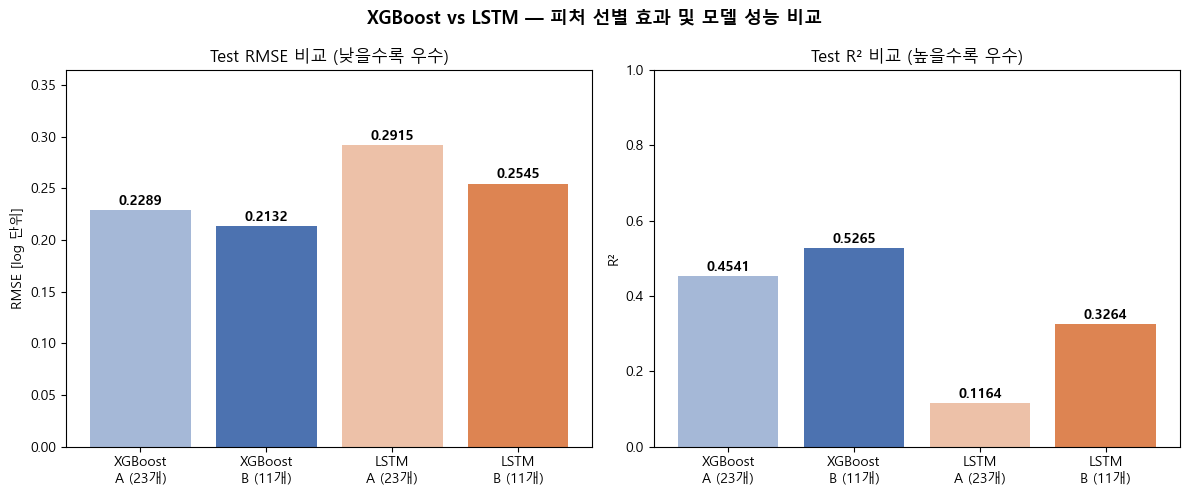

시각화 저장 완료: xgb_lstm_comparison.png


In [26]:
# ══════════════════════════════════════════════════════════════════════════
# Step 12. 4-way 최종 비교 (XGBoost A/B  vs  LSTM A/B)
# ══════════════════════════════════════════════════════════════════════════

results = {
    'XGBoost-A (23개)': res_A,
    'XGBoost-B (11개)': res_B,
    'LSTM-A    (23개)': res_lstm_A,
    'LSTM-B    (11개)': res_lstm_B,
}

# ── 텍스트 비교표 ────────────────────────────────────────────────────────
sep = '=' * 60
print(f'\n{sep}')
print('  4-way 최종 비교')
print(sep)
print(f'  {"모델":<22s}  {"Test RMSE":>10s}  {"Test R²":>10s}')
print(f'  {"-" * 48}')
for name, res in results.items():
    print(f'  {name:<22s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>10.4f}')

# ── 효과 분해 ────────────────────────────────────────────────────────────
xgb_feat   = (res_A['test_rmse']      - res_B['test_rmse'])      / res_A['test_rmse']      * 100
lstm_feat  = (res_lstm_A['test_rmse'] - res_lstm_B['test_rmse']) / res_lstm_A['test_rmse'] * 100
model_full = (res_A['test_rmse']      - res_lstm_A['test_rmse']) / res_A['test_rmse']      * 100
model_sel  = (res_B['test_rmse']      - res_lstm_B['test_rmse']) / res_B['test_rmse']      * 100

print(f'\n  [피처 선별 효과 (A → B)]')
print(f'    XGBoost : RMSE {xgb_feat:+.2f}%')
print(f'    LSTM    : RMSE {lstm_feat:+.2f}%')
print(f'\n  [모델 효과 (XGBoost → LSTM)]')
print(f'    23개 피처 : RMSE {model_full:+.2f}%')
print(f'    11개 피처 : RMSE {model_sel:+.2f}%')
print('\n  ※ RMSE 단위: log(% Silica Concentrate)')
print('  ※ XGBoost: 10-fold CV | LSTM: EarlyStopping + val_split 10%')

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['XGBoost\nA (23개)', 'XGBoost\nB (11개)', 'LSTM\nA (23개)', 'LSTM\nB (11개)']
rmses  = [res_A['test_rmse'], res_B['test_rmse'], res_lstm_A['test_rmse'], res_lstm_B['test_rmse']]
r2s    = [res_A['test_r2'],   res_B['test_r2'],   res_lstm_A['test_r2'],  res_lstm_B['test_r2']]
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
alphas = [0.5, 1.0, 0.5, 1.0]  # A는 흐리게, B는 진하게

# RMSE 바 차트
bars = axes[0].bar(labels, rmses, color=colors)
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
for bar, val in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Test RMSE 비교 (낮을수록 우수)', fontsize=12)
axes[0].set_ylabel('RMSE [log 단위]')
axes[0].set_ylim(0, max(rmses) * 1.25)

# R² 바 차트
bars2 = axes[1].bar(labels, r2s, color=colors)
for bar, a in zip(bars2, alphas):
    bar.set_alpha(a)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Test R² 비교 (높을수록 우수)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.0)

plt.suptitle('XGBoost vs LSTM — 피처 선별 효과 및 모델 성능 비교',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_lstm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('시각화 저장 완료: xgb_lstm_comparison.png')